In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from numba import jit

os.makedirs('data', exist_ok=True)

Energy and Acceptance Functions

In [2]:
@jit(nopython=True)
def compute_energy(state, J, h):
    """
    Calculate the Hamiltonian of a 2D Ising model with periodic boundaries.
    Optimized with Numba JIT compilation.
    """
    rows, cols = state.shape
    H = 0.0
    
    for i in range(rows):
        for j in range(cols):
            s = state[i, j]
            # Right and bottom neighbors (count each pair once)
            H -= J * s * state[i, (j + 1) % cols]
            H -= J * s * state[(i + 1) % rows, j]
            # External field
            H -= h * s
    
    return H

@jit(nopython=True)
def compute_local_energy_change(state, i, j, J, h):
    """Compute energy change when flipping spin at (i, j)."""
    rows, cols = state.shape
    s = state[i, j]
    
    neighbors = (
        state[(i + 1) % rows, j] +
        state[(i - 1) % rows, j] +
        state[i, (j + 1) % cols] +
        state[i, (j - 1) % cols]
    )
    
    return 2 * s * (J * neighbors + h)

@jit(nopython=True)
def compute_magnetization(state):
    """Compute total magnetization per spin."""
    return np.sum(state) / state.size

Metropolis Algorithm

In [3]:
@jit(nopython=True)
def metropolis_step(state, beta, J, h):
    """
    Perform one Metropolis update step (single spin flip).
    Returns the new state and whether it was accepted.
    """
    rows, cols = state.shape
    
    # Random spin selection
    i = np.random.randint(0, rows)
    j = np.random.randint(0, cols)
    
    # Compute energy change
    delta_E = compute_local_energy_change(state, i, j, J, h)
    
    # Metropolis acceptance criterion
    if delta_E <= 0 or np.random.random() < np.exp(-beta * delta_E):
        state[i, j] *= -1
        return delta_E, True
    
    return 0.0, False


@jit(nopython=True)
def run_metropolis(state, beta, J, h, n_steps, record_interval=1):
    """
    Run Metropolis algorithm with efficient energy tracking.
    
    Parameters:
    -----------
    state : np.ndarray
        Initial spin configuration (modified in place)
    beta : float
        Inverse temperature
    J : float
        Coupling constant
    h : float
        External field
    n_steps : int
        Number of Monte Carlo steps
    record_interval : int
        Record observables every N steps (default: 1)
    
    Returns:
    --------
    energies : np.ndarray
        Energy at each recorded step
    magnetizations : np.ndarray
        Magnetization at each recorded step
    acceptance_rate : float
        Fraction of accepted moves
    """
    n_records = n_steps // record_interval + 1
    energies = np.zeros(n_records)
    magnetizations = np.zeros(n_records)
    
    # Initial observables
    current_energy = compute_energy(state, J, h)
    energies[0] = current_energy
    magnetizations[0] = compute_magnetization(state)
    
    accepted = 0
    record_idx = 1
    
    for step in range(1, n_steps + 1):
        delta_E, was_accepted = metropolis_step(state, beta, J, h)
        
        if was_accepted:
            current_energy += delta_E
            accepted += 1
        
        # Record observables at intervals
        if step % record_interval == 0:
            energies[record_idx] = current_energy
            magnetizations[record_idx] = compute_magnetization(state)
            record_idx += 1
    
    acceptance_rate = accepted / n_steps
    return energies, magnetizations, acceptance_rate

@jit(nopython=True)
def run_burnin(state, beta, J, h, n_steps):
    """
    Run burn-in without recording data (faster).
    
    Parameters:
    -----------
    state : np.ndarray
        Initial spin configuration (modified in place)
    beta : float
        Inverse temperature
    J : float
        Coupling constant
    h : float
        External field
    n_steps : int
        Number of burn-in steps
    
    Returns:
    --------
    acceptance_rate : float
        Fraction of accepted moves during burn-in
    """
    accepted = 0
    
    for _ in range(n_steps):
        _, was_accepted = metropolis_step(state, beta, J, h)
        if was_accepted:
            accepted += 1
    
    return accepted / n_steps

Utility Functions

In [13]:
def generate_initial_state(L, random_init=True):
    """
    Generate initial spin configuration.
    
    Parameters:
    -----------
    L : int
        Lattice size (L x L)
    random_init : bool
        If True, random spins; if False, all spins up
    """
    if random_init:
        return np.random.choice([-1, 1], size=(L, L))
    else:
        return np.ones((L, L), dtype=np.int8)

def plot_results(energies, magnetizations, title_suffix="", 
                 burnin_shown=False, save_path=None):
    """Plot energy and magnetization over simulation steps."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    steps = np.arange(len(energies))
    
    ax1.plot(steps, energies, linewidth=0.8, alpha=0.8)
    ax1.set_xlabel('Monte Carlo Steps', fontsize=12)
    ax1.set_ylabel('Energy', fontsize=12)
    title = f'Energy vs Steps {title_suffix}'
    if not burnin_shown:
        title += ' (Post-Burnin)'
    ax1.set_title(title, fontsize=14)
    ax1.grid(alpha=0.3)
    
    ax2.plot(steps, magnetizations, linewidth=0.8, alpha=0.8, color='red')
    ax2.set_xlabel('Monte Carlo Steps', fontsize=12)
    ax2.set_ylabel('Magnetization', fontsize=12)
    title = f'Magnetization vs Steps {title_suffix}'
    if not burnin_shown:
        title += ' (Post-Burnin)'
    ax2.set_title(title, fontsize=14)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Plot saved: {save_path}")
    
    plt.show()

def plot_spin_configuration(state, title="Spin Configuration", save_path=None):
    """Visualize the spin lattice."""
    plt.figure(figsize=(8, 8))
    plt.imshow(state, cmap='RdBu', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar(label='Spin', ticks=[-1, 1])
    plt.title(title, fontsize=14)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Plot saved: {save_path}")
    
    plt.show()

def compute_statistics(energies, magnetizations):
    """
    Compute statistical properties from equilibrated data.
    
    Parameters:
    -----------
    energies : np.ndarray
        Energy time series (should be post-burnin)
    magnetizations : np.ndarray
        Magnetization time series (should be post-burnin)
    
    Returns:
    --------
    dict with mean/std of energy and magnetization
    """
    E = energies
    M = np.abs(magnetizations)  # Absolute magnetization
    
    return {
        'mean_energy': np.mean(E),
        'std_energy': np.std(E),
        'mean_magnetization': np.mean(M),
        'std_magnetization': np.std(M),
        'specific_heat_proxy': np.var(E),
        'susceptibility_proxy': np.var(M)
    }

Simulation Function

In [ ]:
def simulate_ising_model(L=20, T=2.27, J=1.0, h=0.0, n_steps=10000, 
                         burnin_steps=None, record_interval=1, 
                         random_init=True, show_plots=True, 
                         initial_state=None, save_plots_prefix=None):
    """
    Run complete Ising model simulation with proper burn-in.
    
    Parameters:
    -----------
    L : int
        Lattice size
    T : float
        Temperature
    J : float
        Coupling constant
    h : float
        External magnetic field
    n_steps : int
        Number of Monte Carlo steps (production run)
    burnin_steps : int or None
        Number of burn-in steps (auto-calculated if None)
    record_interval : int
        Record observables every N steps
    random_init : bool
        Random or ordered initial state (ignored if initial_state provided)
    show_plots : bool
        Whether to display plots
    initial_state : np.ndarray or None
        Pre-existing state to continue from (skips initialization)
    save_plots_prefix : str or None
        If provided, save plots with this prefix
    
    Returns:
    --------
    dict with results
    """
    beta = 1.0 / T if T > 0 else np.inf
    
    # Determine burn-in steps if not specified
    if burnin_steps is None:
        burnin_steps = determine_burnin_steps(L, beta)
    
    # Initialize or use provided state
    if initial_state is not None:
        state = initial_state.copy()
    else:
        state = generate_initial_state(L, random_init)
    
    print(f"Running simulation: L={L}, T={T:.3f}, J={J}, h={h}")
    print(f"Burn-in steps: {burnin_steps}")
    print(f"Production steps: {n_steps}, Recording every {record_interval} steps")
    
    # Phase 1: Burn-in (equilibration)
    print("Phase 1: Burn-in...", end=" ", flush=True)
    burnin_acceptance = run_burnin(state, beta, J, h, burnin_steps)
    print(f"Complete (acceptance rate: {burnin_acceptance:.3f})")
    
    # Phase 2: Production run (data collection)
    print("Phase 2: Production run...", end=" ", flush=True)
    energies, magnetizations, acceptance_rate = run_metropolis(
        state, beta, J, h, n_steps, record_interval
    )
    print(f"Complete (acceptance rate: {acceptance_rate:.3f})")
    
    # Compute statistics from equilibrated data
    stats = compute_statistics(energies, magnetizations)
    
    print("\nEquilibrium Statistics:")
    print(f"  <E> = {stats['mean_energy']:.4f} ± {stats['std_energy']:.4f}")
    print(f"  <|M|> = {stats['mean_magnetization']:.4f} ± "
          f"{stats['std_magnetization']:.4f}")
    
    # Plotting
    if show_plots:
        # Prepare save paths if prefix is provided
        timeseries_path = None
        config_path = None
        if save_plots_prefix:
            timeseries_path = f"{save_plots_prefix}_timeseries.png"
            config_path = f"{save_plots_prefix}_config.png"
        
        # Plot time series
        plot_results(
            energies, magnetizations, 
            f"(L={L}, T={T:.2f}, J={J}, h={h})",
            save_path=timeseries_path
        )
        
        # Plot final configuration
        plot_spin_configuration(
            state, 
            f"Final Configuration (T={T:.2f})",
            save_path=config_path
        )
    
    return {
        'state': state,
        'energies': energies,
        'magnetizations': magnetizations,
        'acceptance_rate': acceptance_rate,
        'burnin_acceptance': burnin_acceptance,
        'statistics': stats,
        'parameters': {
            'L': L, 'T': T, 'J': J, 'h': h, 
            'n_steps': n_steps, 'burnin_steps': burnin_steps
        }
    }

def determine_burnin_steps(L, beta, beta_c=0.4407):
    """
    Conservative burn-in for critical exponent measurements.
    Over-estimates to ensure equilibration without using autocorrelation.
    """
    # Base: 10 full lattice sweeps
    base_burnin = L * L * 10
    
    # Critical slowing down scaling
    delta_beta = abs(beta - beta_c)
    
    if delta_beta < 0.005:  # Very close to critical point
        return base_burnin * 100  # 1000 L²
    elif delta_beta < 0.01:
        return base_burnin * 50   # 500 L²
    elif delta_beta < 0.02:
        return base_burnin * 20   # 200 L²
    elif delta_beta < 0.05:
        return base_burnin * 10   # 100 L²
    else:
        return base_burnin        # 10 L²

Simulation

Starting temperature scan: 16 temperatures
Lattice: 100x100, Production steps: 100000

[1/16] Simulating beta = 0.1000 (T = 10.0000)
Running simulation: L=100, T=10.000, J=1.0, h=0.0
Burn-in steps: 50000
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.853)
Phase 2: Production run... Complete (acceptance rate: 0.849)

Equilibrium Statistics:
  <E> = -2055.4925 ± 115.0884
  <|M|> = 0.0098 ± 0.0066
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.1000_timeseries.png


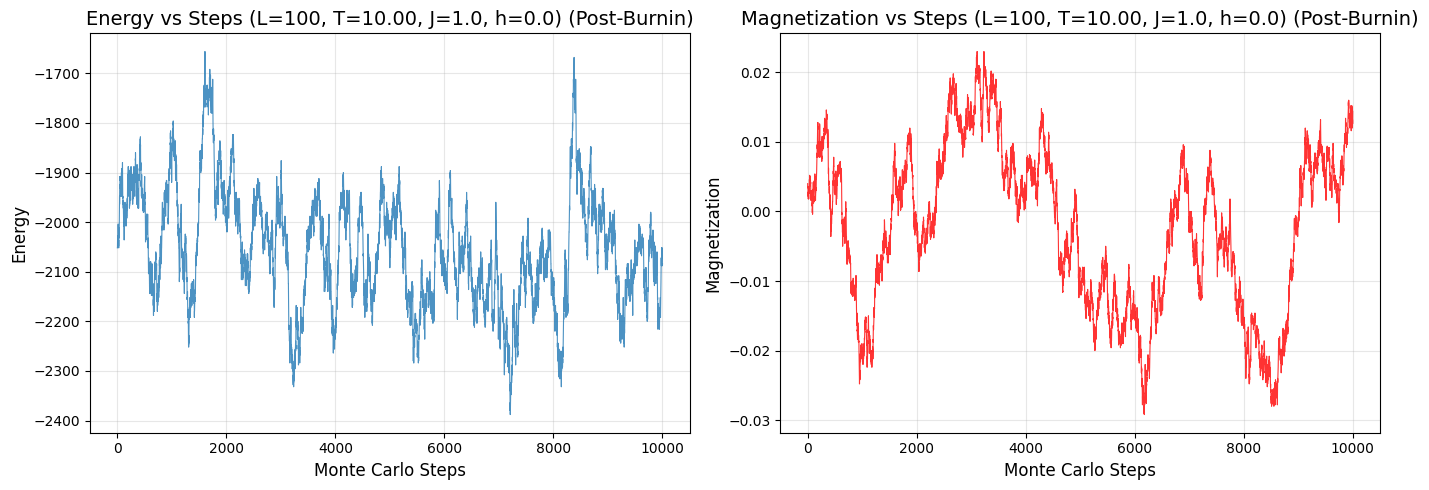

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.1000_config.png


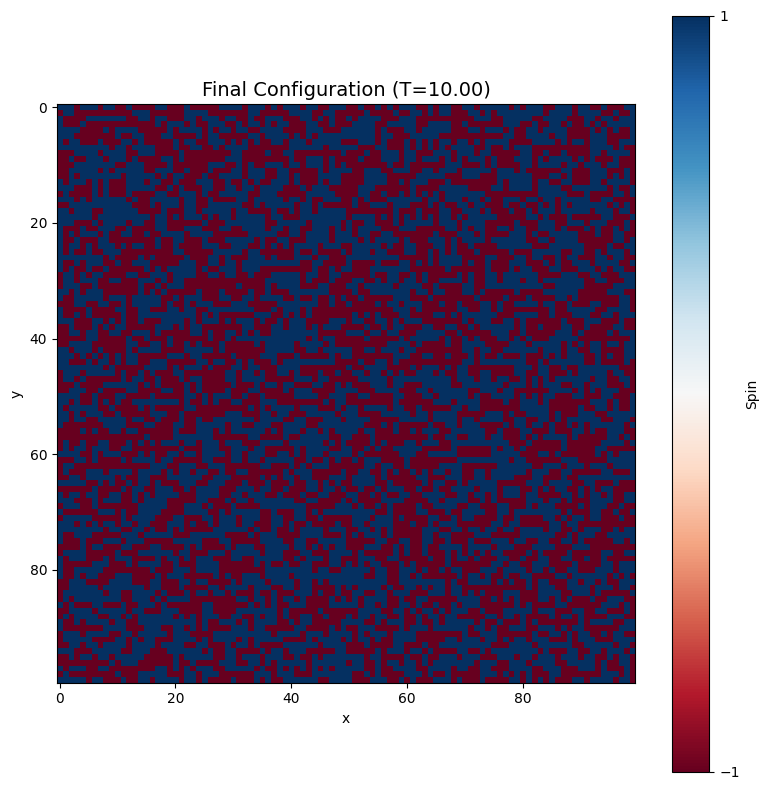

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.1.npz

[2/16] Simulating beta = 0.2000 (T = 5.0000)
Running simulation: L=100, T=5.000, J=1.0, h=0.0
Burn-in steps: 16666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.719)
Phase 2: Production run... Complete (acceptance rate: 0.692)

Equilibrium Statistics:
  <E> = -4226.3622 ± 126.2496
  <|M|> = 0.0119 ± 0.0076
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.2000_timeseries.png


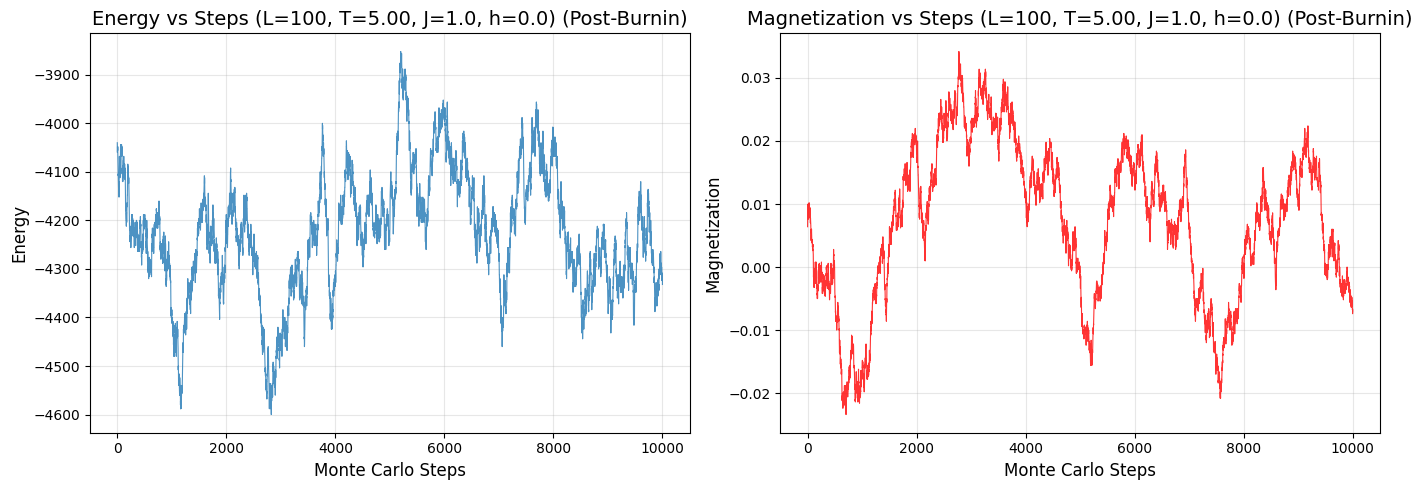

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.2000_config.png


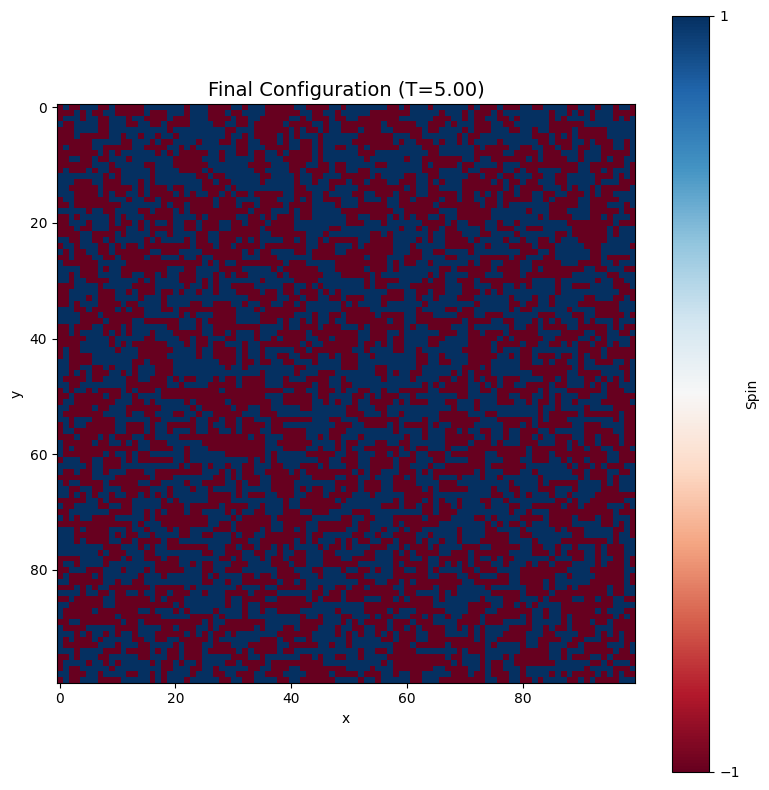

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.2.npz

[3/16] Simulating beta = 0.3000 (T = 3.3333)
Running simulation: L=100, T=3.333, J=1.0, h=0.0
Burn-in steps: 16666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.563)
Phase 2: Production run... Complete (acceptance rate: 0.529)

Equilibrium Statistics:
  <E> = -6813.0435 ± 164.5366
  <|M|> = 0.0107 ± 0.0092
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.3000_timeseries.png


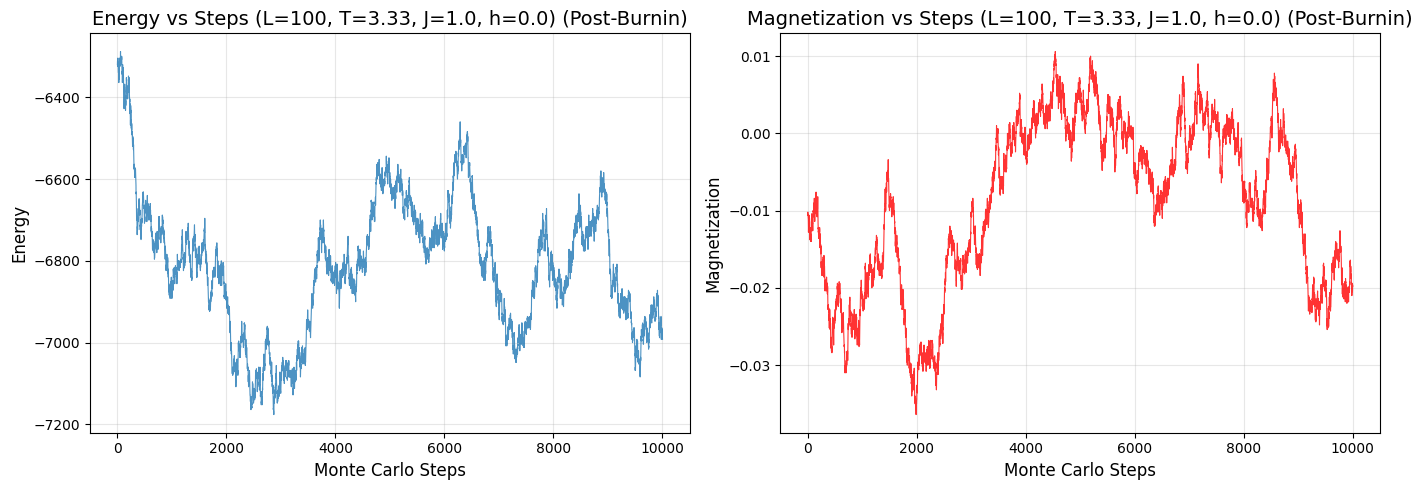

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.3000_config.png


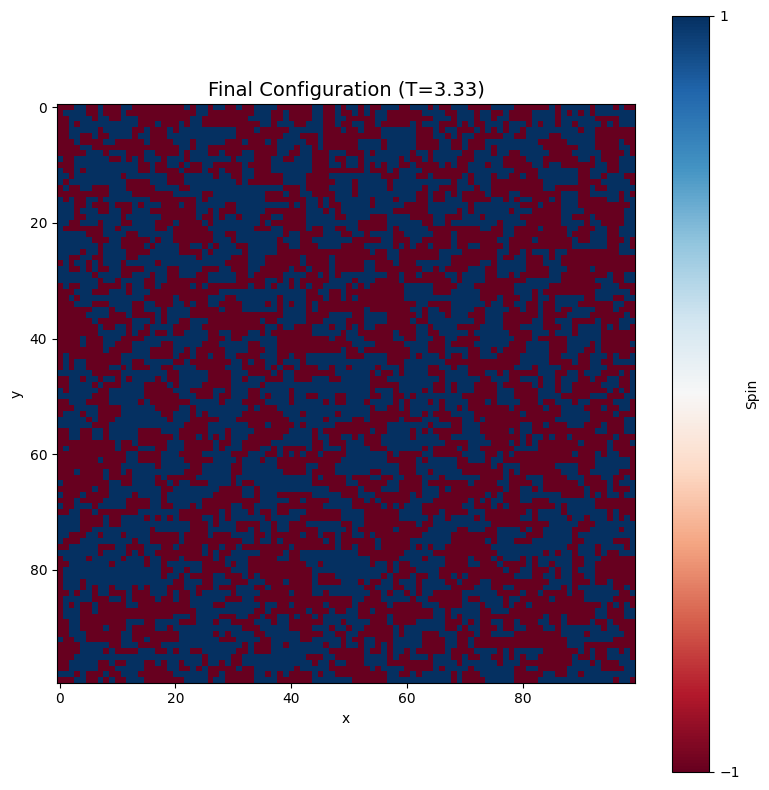

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.3.npz

[4/16] Simulating beta = 0.4000 (T = 2.5000)
Running simulation: L=100, T=2.500, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.382)
Phase 2: Production run... Complete (acceptance rate: 0.335)

Equilibrium Statistics:
  <E> = -10766.8157 ± 132.1003
  <|M|> = 0.0283 ± 0.0115
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4000_timeseries.png


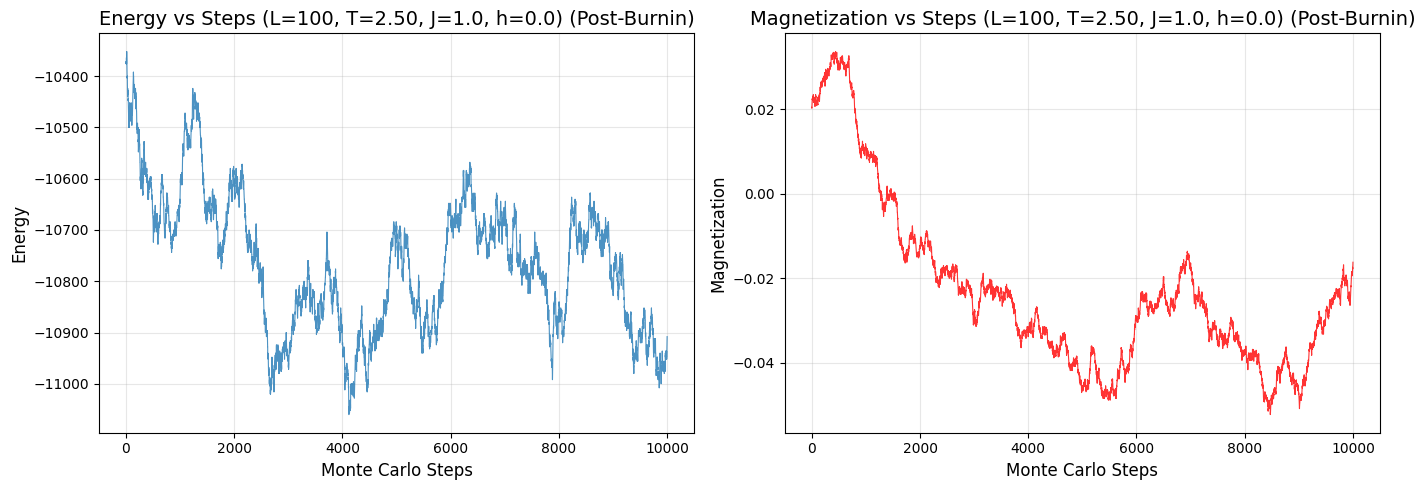

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4000_config.png


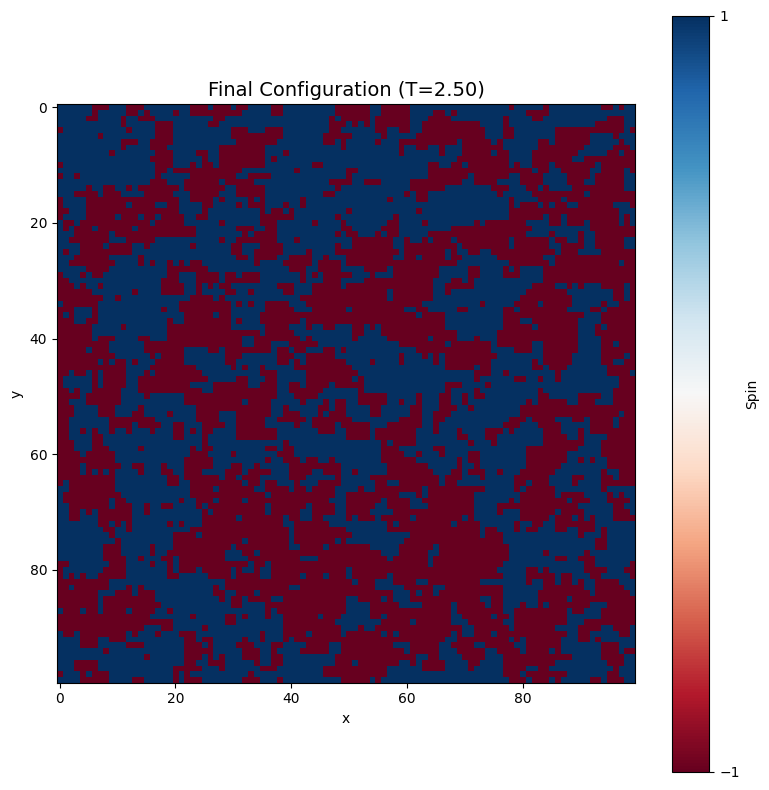

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.4.npz

[5/16] Simulating beta = 0.4100 (T = 2.4390)
Running simulation: L=100, T=2.439, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.312)
Phase 2: Production run... Complete (acceptance rate: 0.303)

Equilibrium Statistics:
  <E> = -11553.0223 ± 99.9132
  <|M|> = 0.0135 ± 0.0076
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4100_timeseries.png


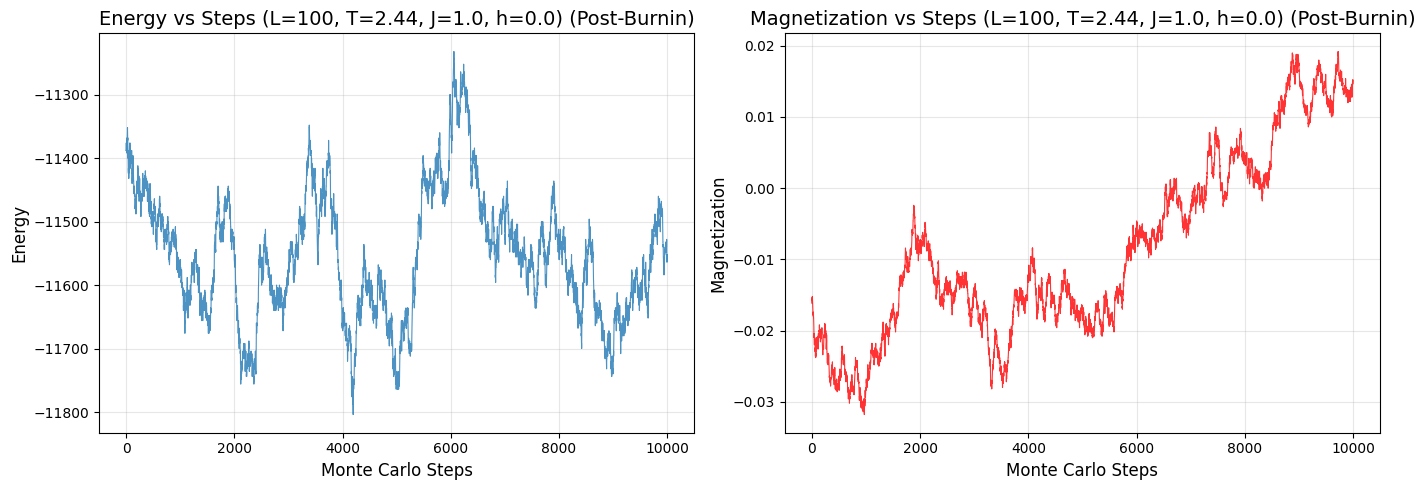

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4100_config.png


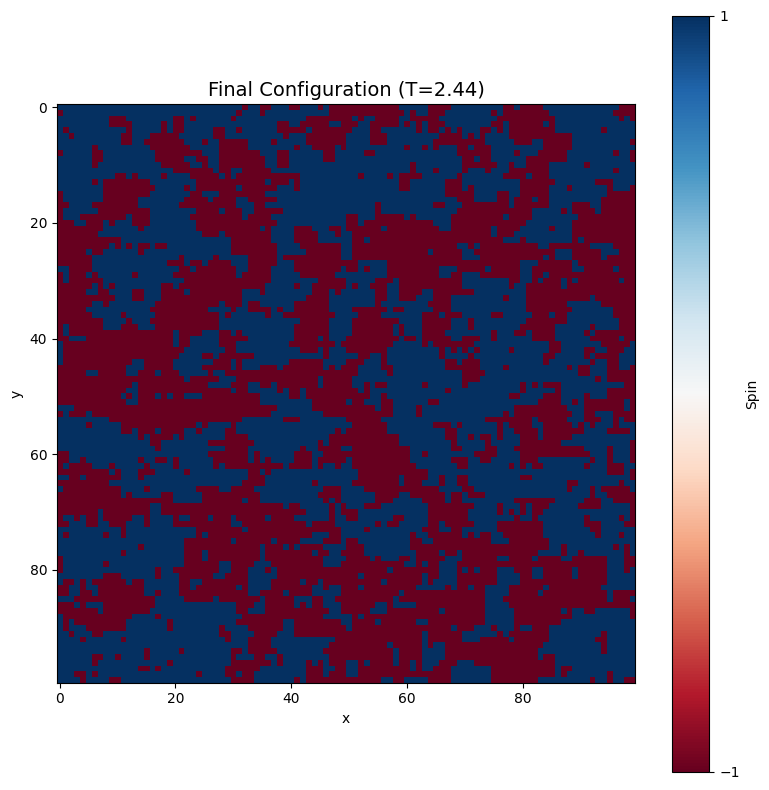

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.41.npz

[6/16] Simulating beta = 0.4200 (T = 2.3810)
Running simulation: L=100, T=2.381, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.293)
Phase 2: Production run... Complete (acceptance rate: 0.280)

Equilibrium Statistics:
  <E> = -12031.0841 ± 171.8318
  <|M|> = 0.0069 ± 0.0049
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4200_timeseries.png


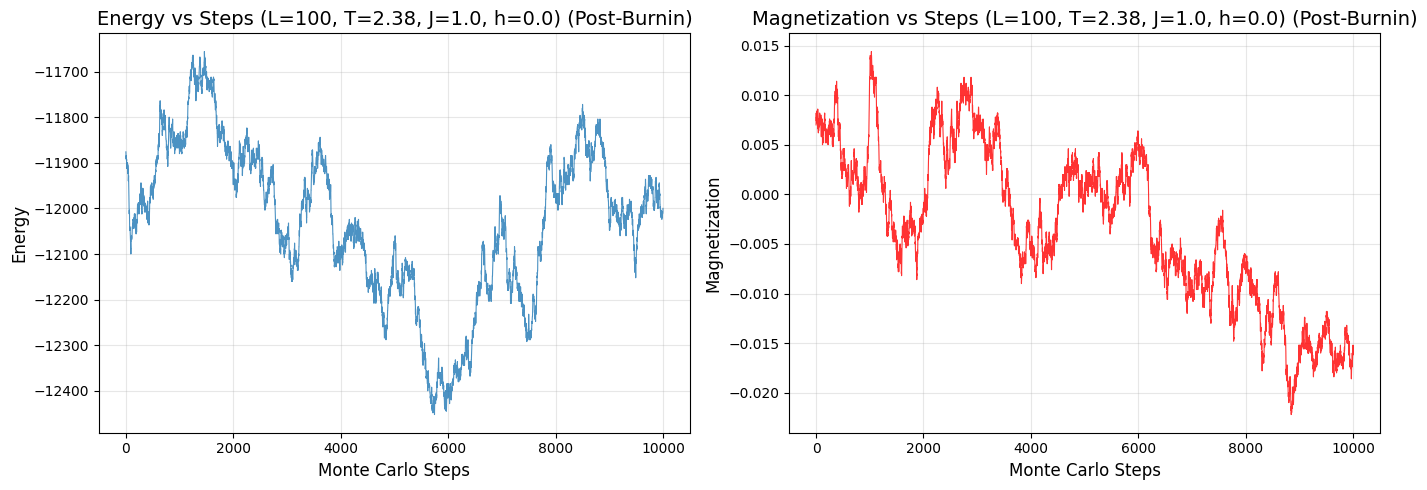

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4200_config.png


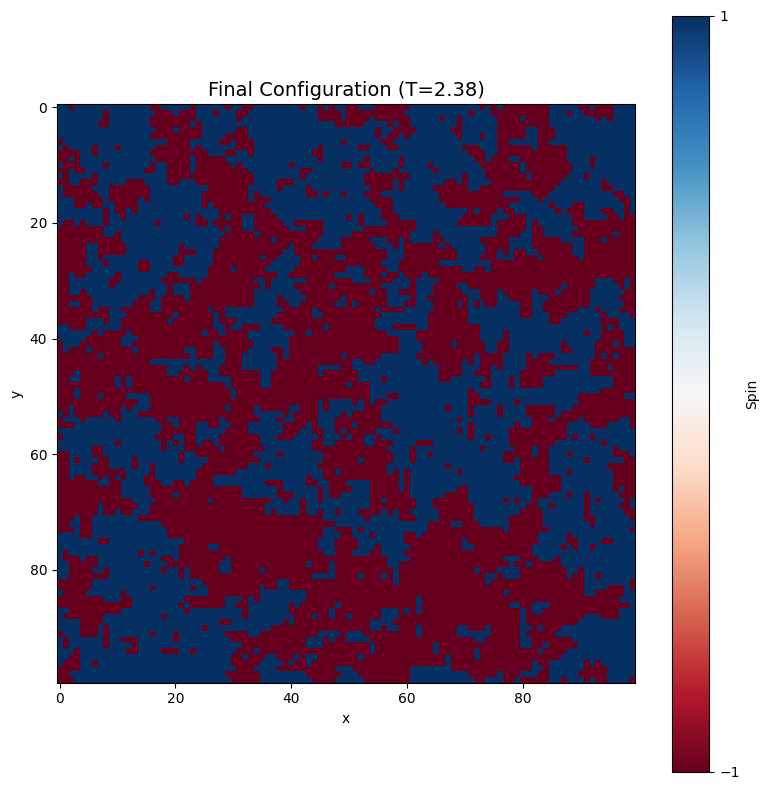

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.42.npz

[7/16] Simulating beta = 0.4300 (T = 2.3256)
Running simulation: L=100, T=2.326, J=1.0, h=0.0
Burn-in steps: 166666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.266)
Phase 2: Production run... Complete (acceptance rate: 0.252)

Equilibrium Statistics:
  <E> = -12733.8342 ± 211.8977
  <|M|> = 0.0123 ± 0.0070
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4300_timeseries.png


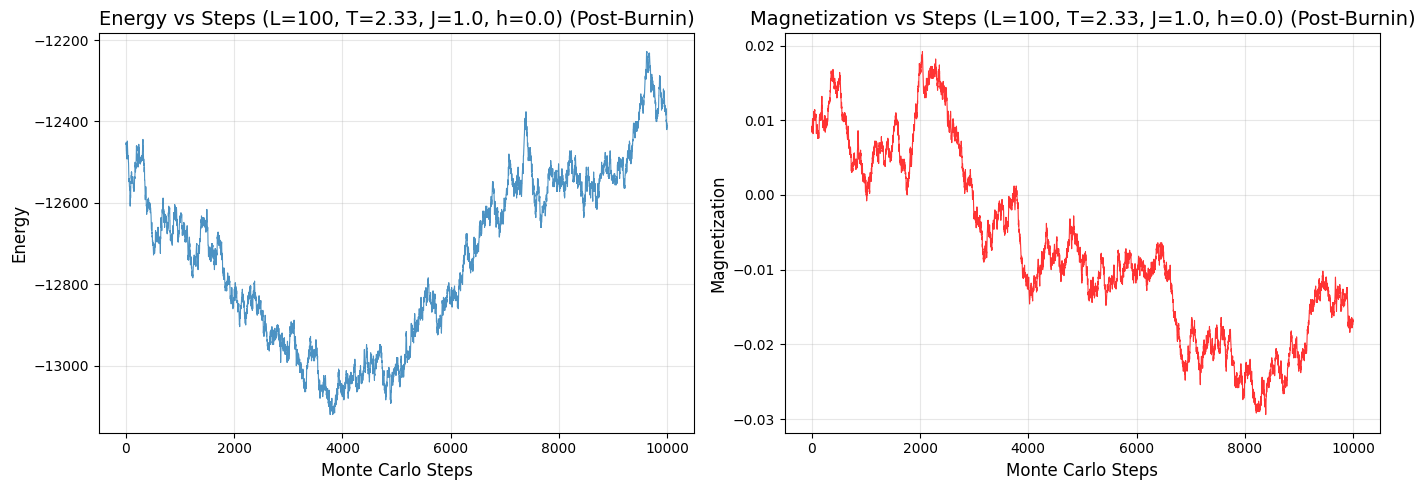

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4300_config.png


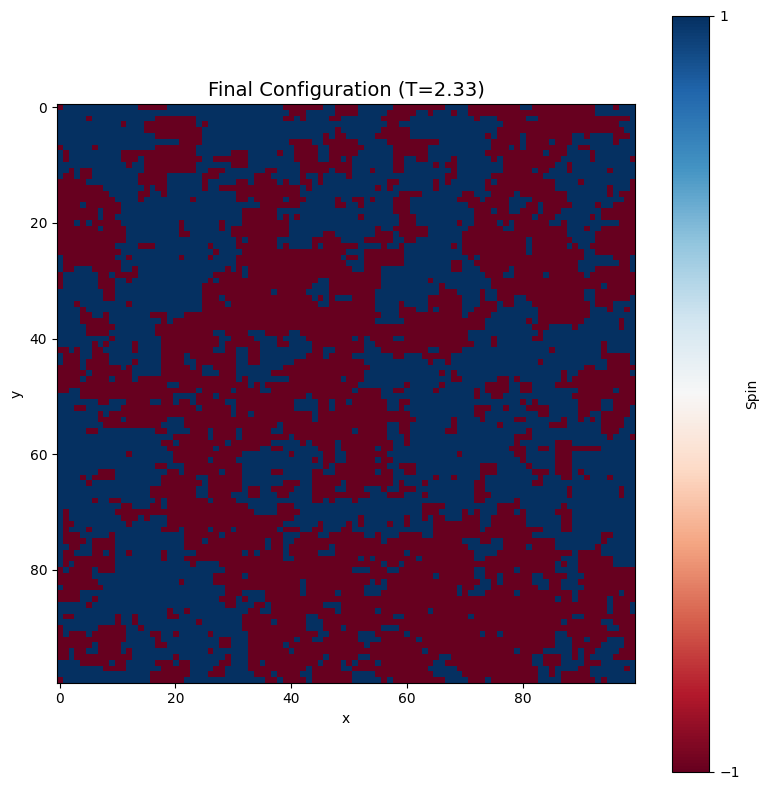

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.43.npz

[8/16] Simulating beta = 0.4400 (T = 2.2727)
Running simulation: L=100, T=2.273, J=1.0, h=0.0
Burn-in steps: 166666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.241)
Phase 2: Production run... Complete (acceptance rate: 0.233)

Equilibrium Statistics:
  <E> = -13253.0519 ± 146.9078
  <|M|> = 0.0516 ± 0.0119
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4400_timeseries.png


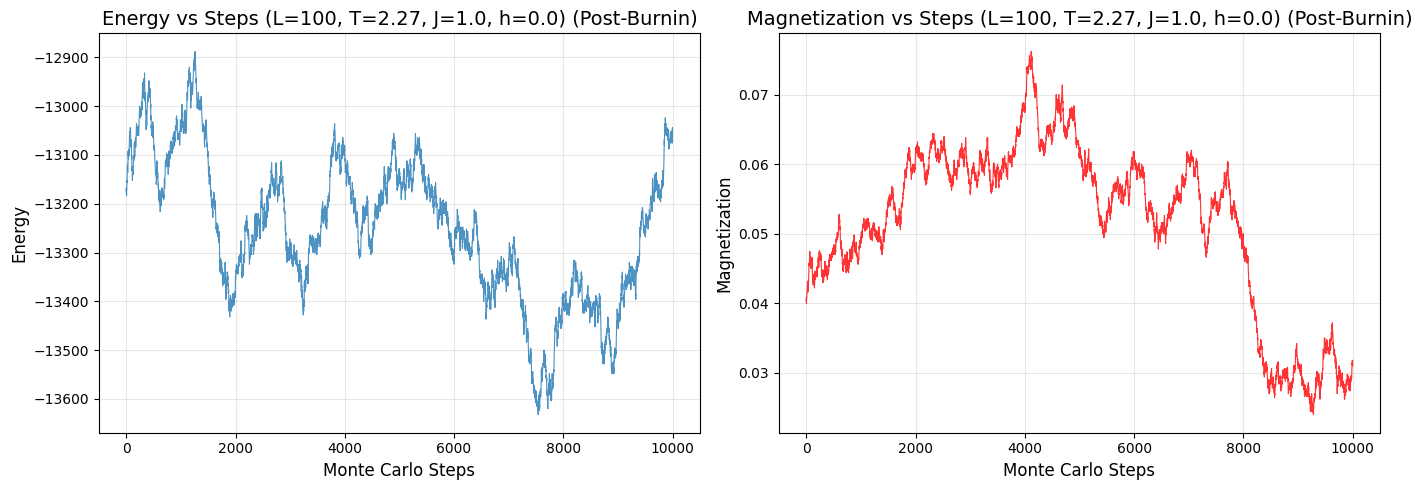

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4400_config.png


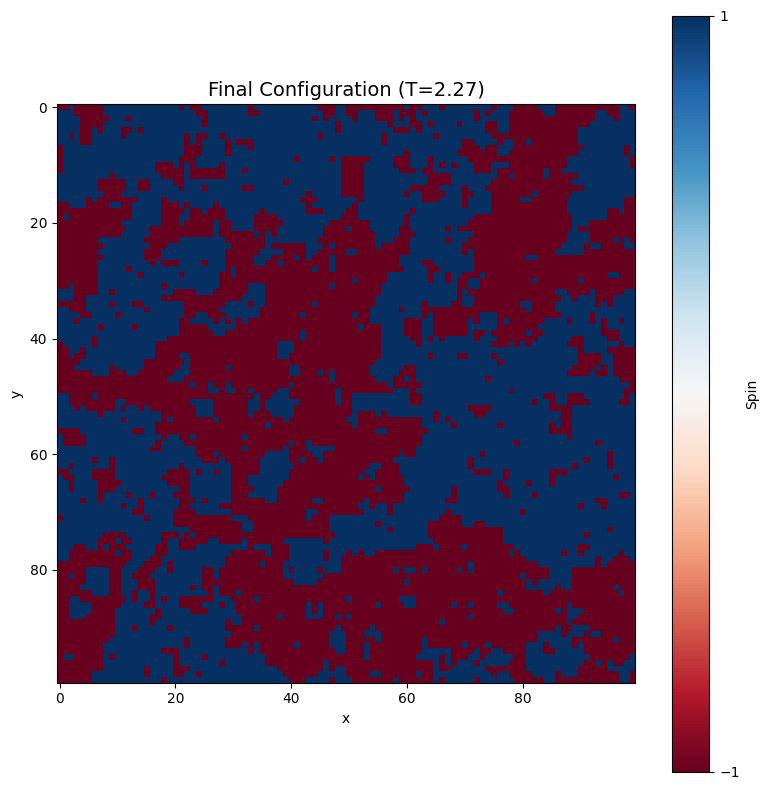

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.44.npz

[9/16] Simulating beta = 0.4407 (T = 2.2691)
Running simulation: L=100, T=2.269, J=1.0, h=0.0
Burn-in steps: 166666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.240)
Phase 2: Production run... Complete (acceptance rate: 0.232)

Equilibrium Statistics:
  <E> = -13241.3191 ± 194.3353
  <|M|> = 0.0105 ± 0.0066
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4407_timeseries.png


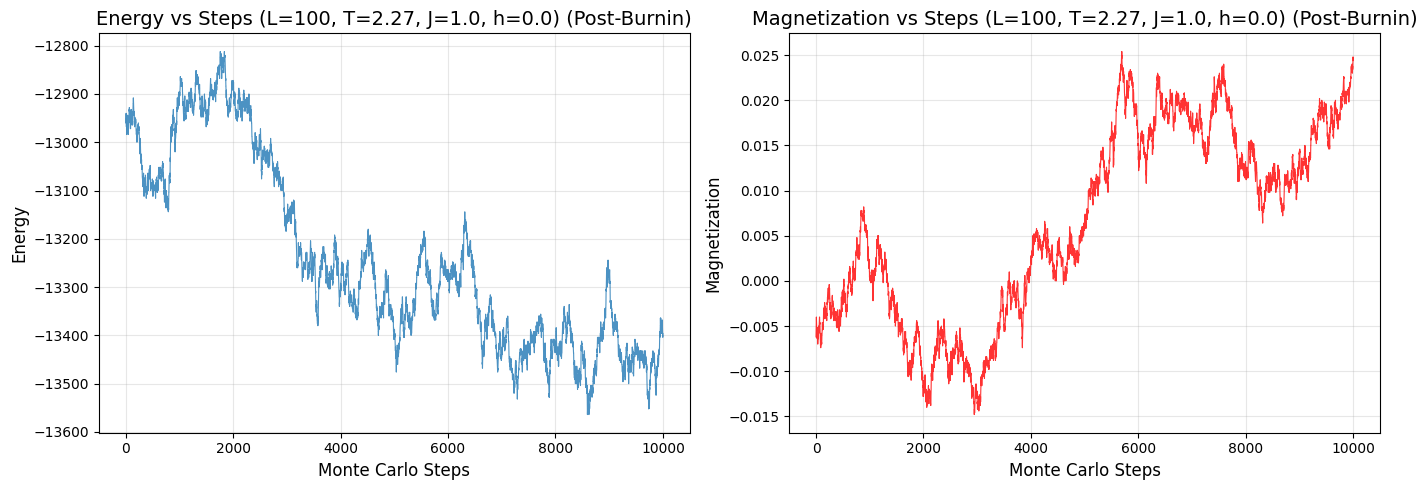

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4407_config.png


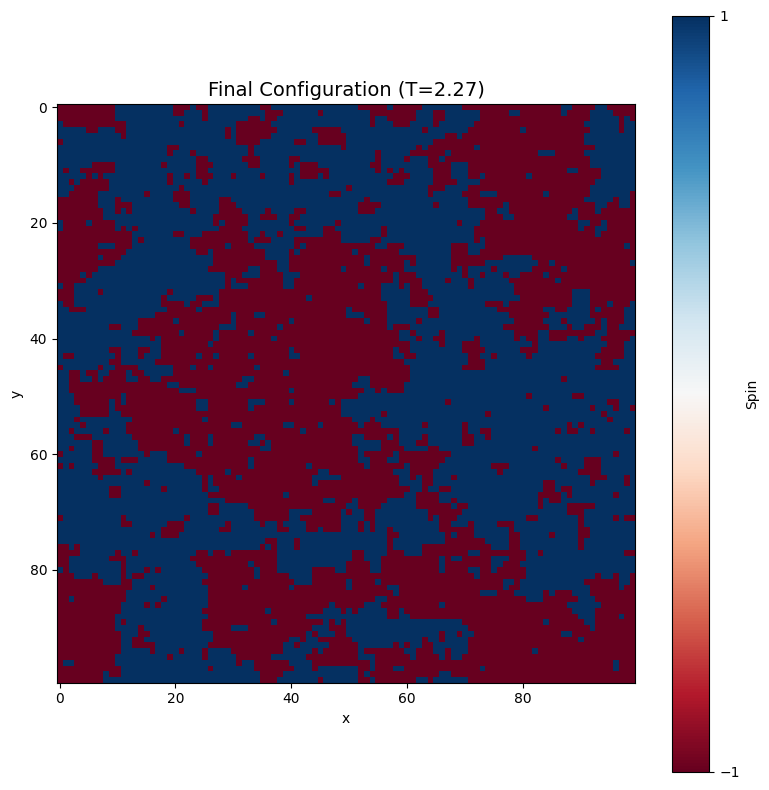

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.4407.npz

[10/16] Simulating beta = 0.4500 (T = 2.2222)
Running simulation: L=100, T=2.222, J=1.0, h=0.0
Burn-in steps: 166666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.220)
Phase 2: Production run... Complete (acceptance rate: 0.204)

Equilibrium Statistics:
  <E> = -14047.6708 ± 94.5172
  <|M|> = 0.0785 ± 0.0066
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4500_timeseries.png


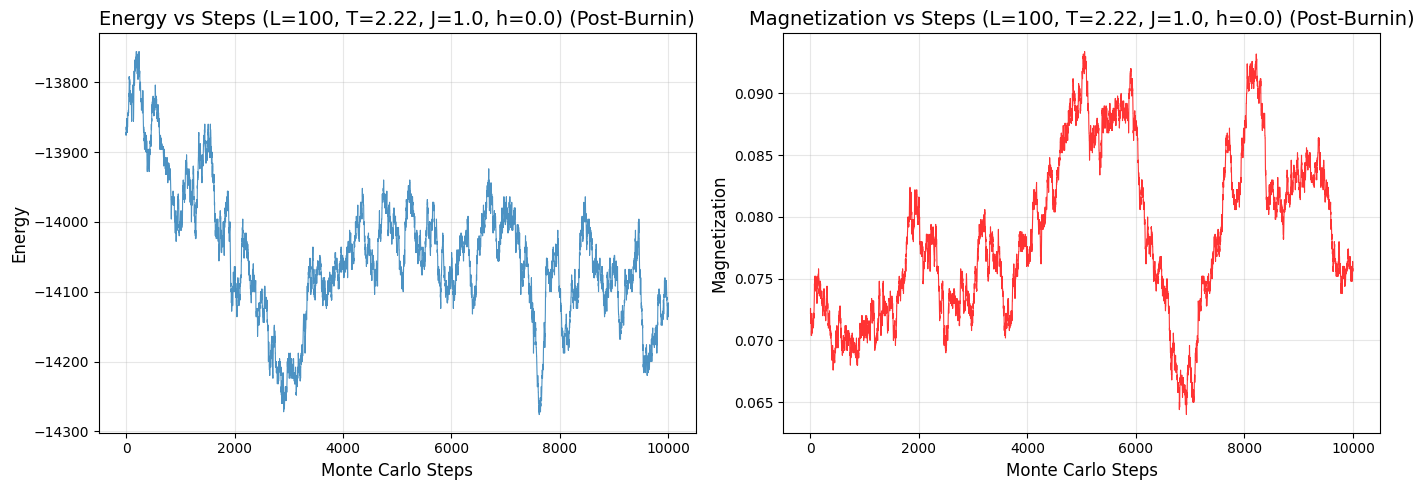

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4500_config.png


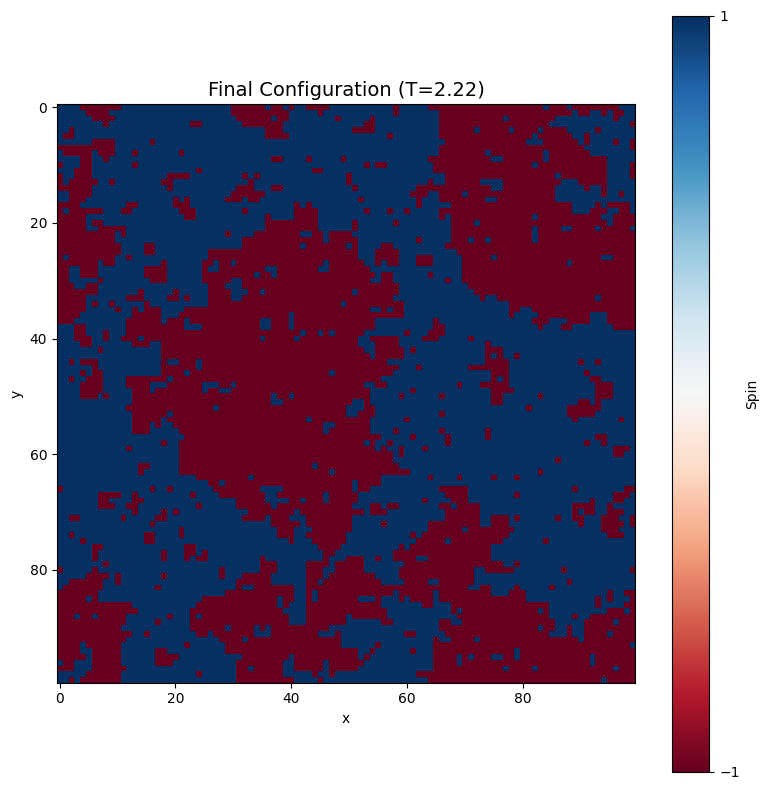

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.45.npz

[11/16] Simulating beta = 0.4600 (T = 2.1739)
Running simulation: L=100, T=2.174, J=1.0, h=0.0
Burn-in steps: 166666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.185)
Phase 2: Production run... Complete (acceptance rate: 0.180)

Equilibrium Statistics:
  <E> = -14686.3762 ± 144.3370
  <|M|> = 0.0433 ± 0.0069
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4600_timeseries.png


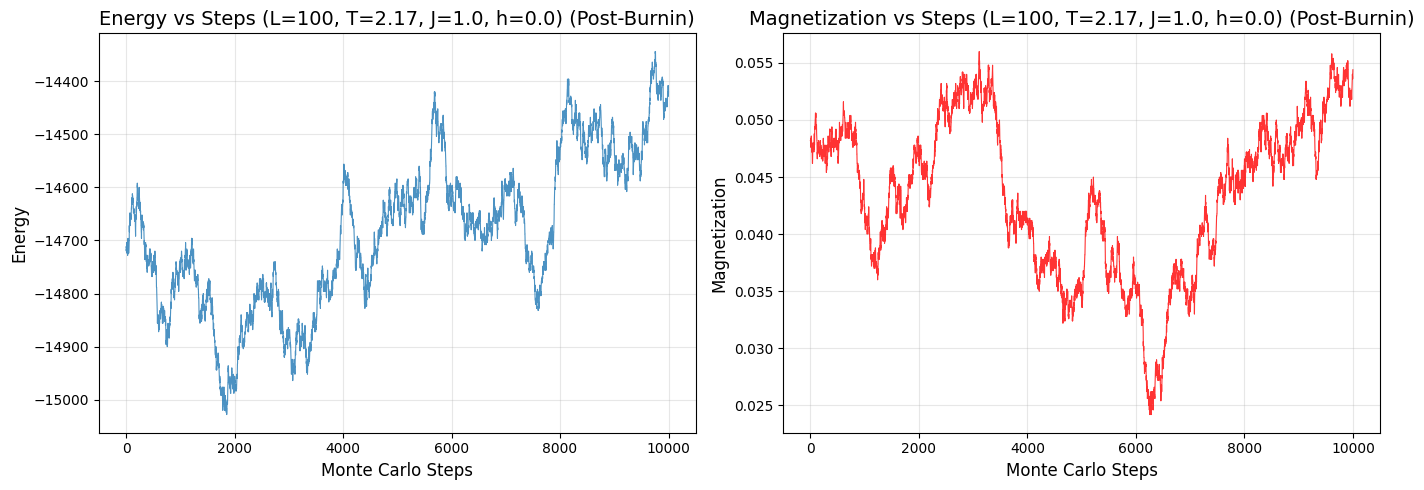

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4600_config.png


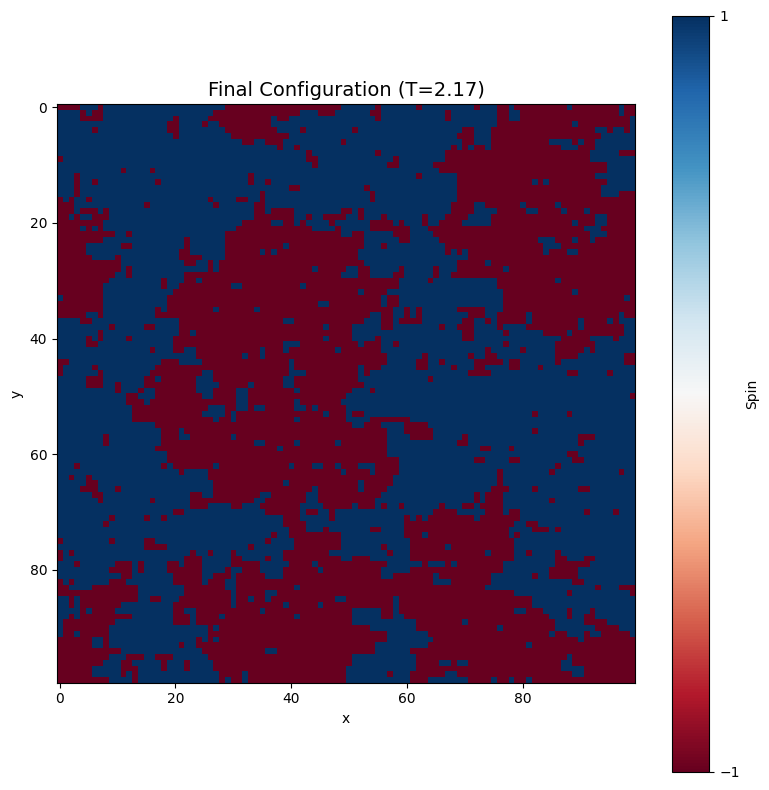

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.46.npz

[12/16] Simulating beta = 0.4700 (T = 2.1277)
Running simulation: L=100, T=2.128, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.170)
Phase 2: Production run... Complete (acceptance rate: 0.169)

Equilibrium Statistics:
  <E> = -14858.6129 ± 104.4504
  <|M|> = 0.0588 ± 0.0092
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4700_timeseries.png


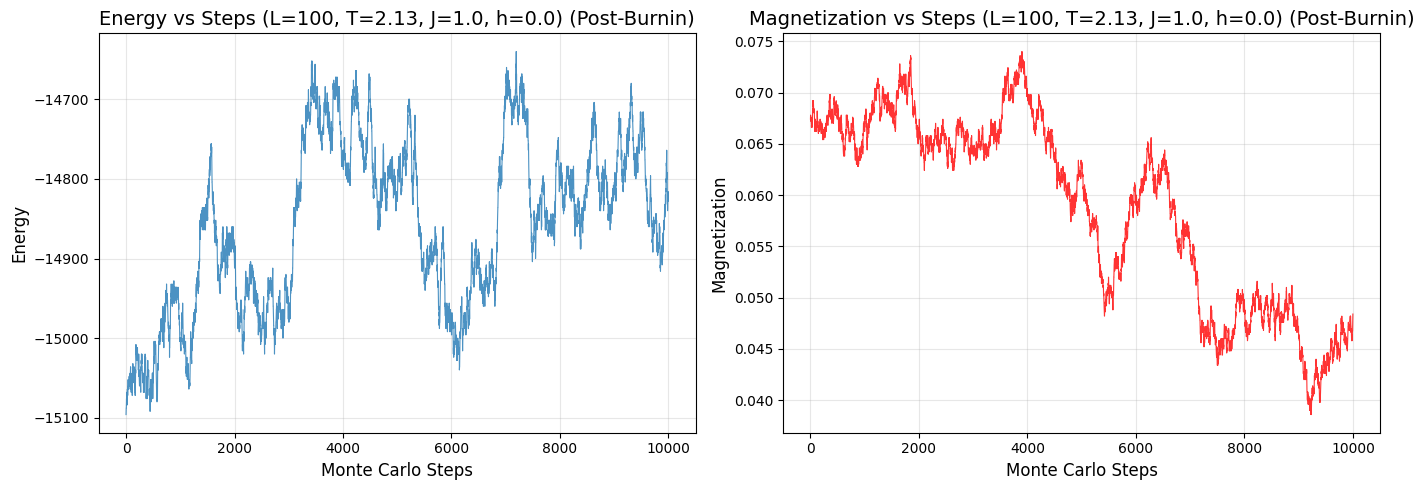

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4700_config.png


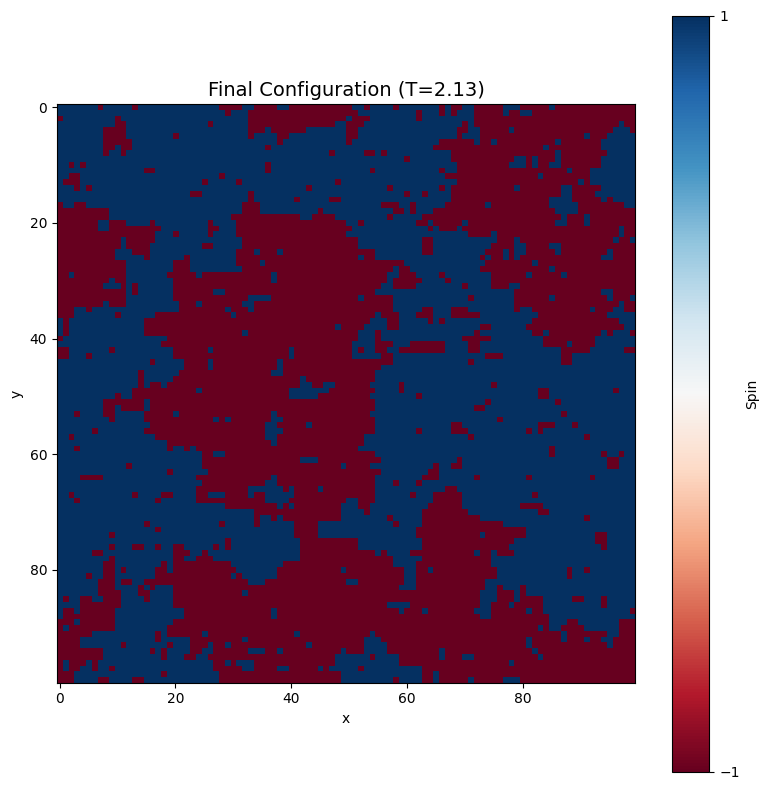

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.47.npz

[13/16] Simulating beta = 0.4800 (T = 2.0833)
Running simulation: L=100, T=2.083, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.163)
Phase 2: Production run... Complete (acceptance rate: 0.152)

Equilibrium Statistics:
  <E> = -15336.6895 ± 211.7667
  <|M|> = 0.0597 ± 0.0068
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4800_timeseries.png


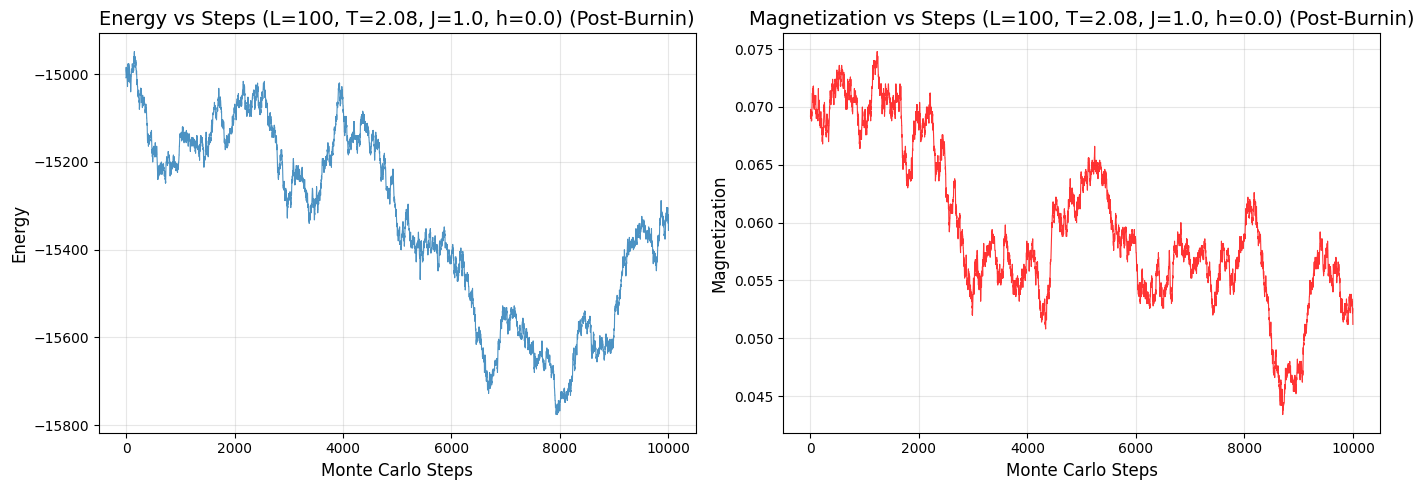

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4800_config.png


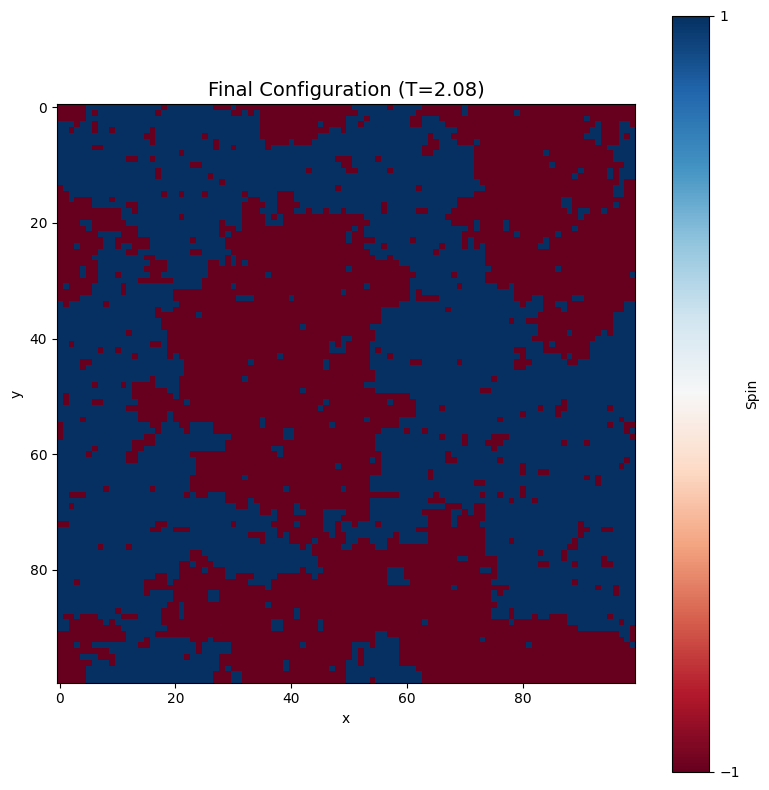

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.48.npz

[14/16] Simulating beta = 0.4900 (T = 2.0408)
Running simulation: L=100, T=2.041, J=1.0, h=0.0
Burn-in steps: 83333
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.138)
Phase 2: Production run... Complete (acceptance rate: 0.134)

Equilibrium Statistics:
  <E> = -15876.7287 ± 121.5763
  <|M|> = 0.0680 ± 0.0104
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4900_timeseries.png


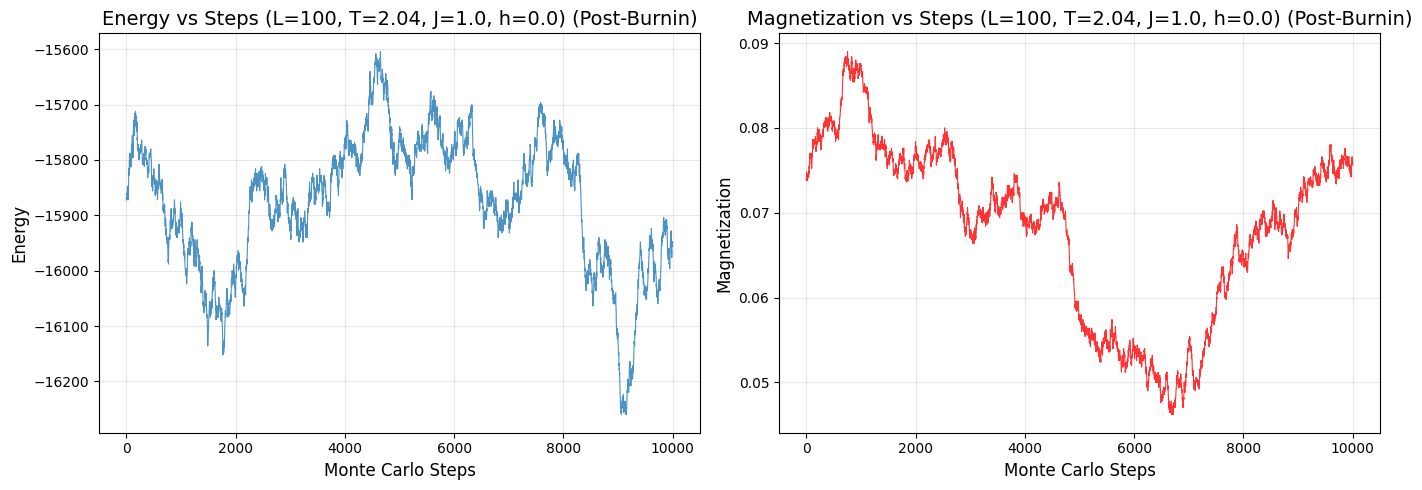

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.4900_config.png


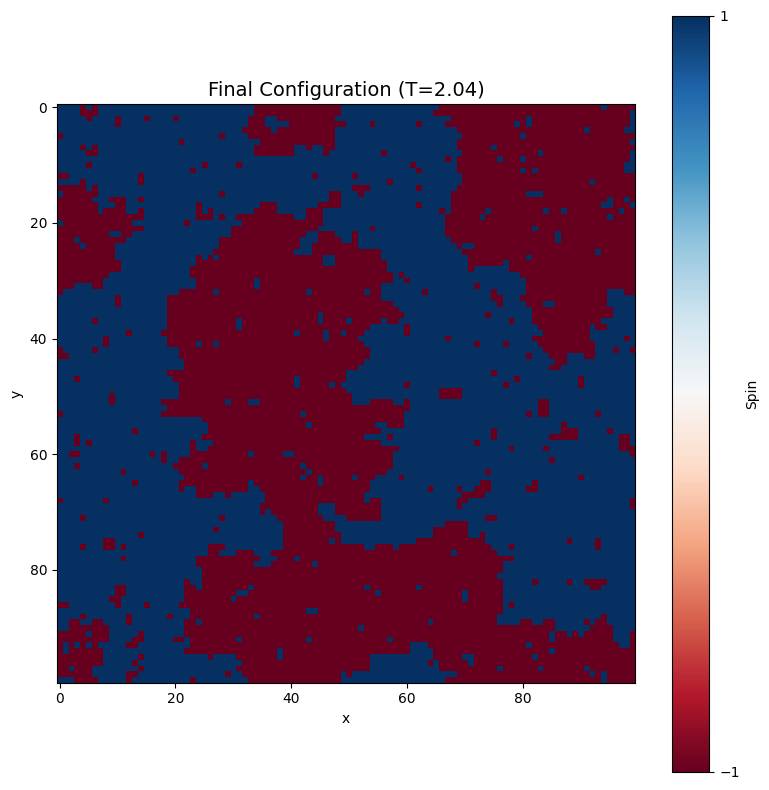

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.49.npz

[15/16] Simulating beta = 0.5000 (T = 2.0000)
Running simulation: L=100, T=2.000, J=1.0, h=0.0
Burn-in steps: 16666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.127)
Phase 2: Production run... Complete (acceptance rate: 0.123)

Equilibrium Statistics:
  <E> = -16128.5295 ± 71.2048
  <|M|> = 0.0803 ± 0.0050
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.5000_timeseries.png


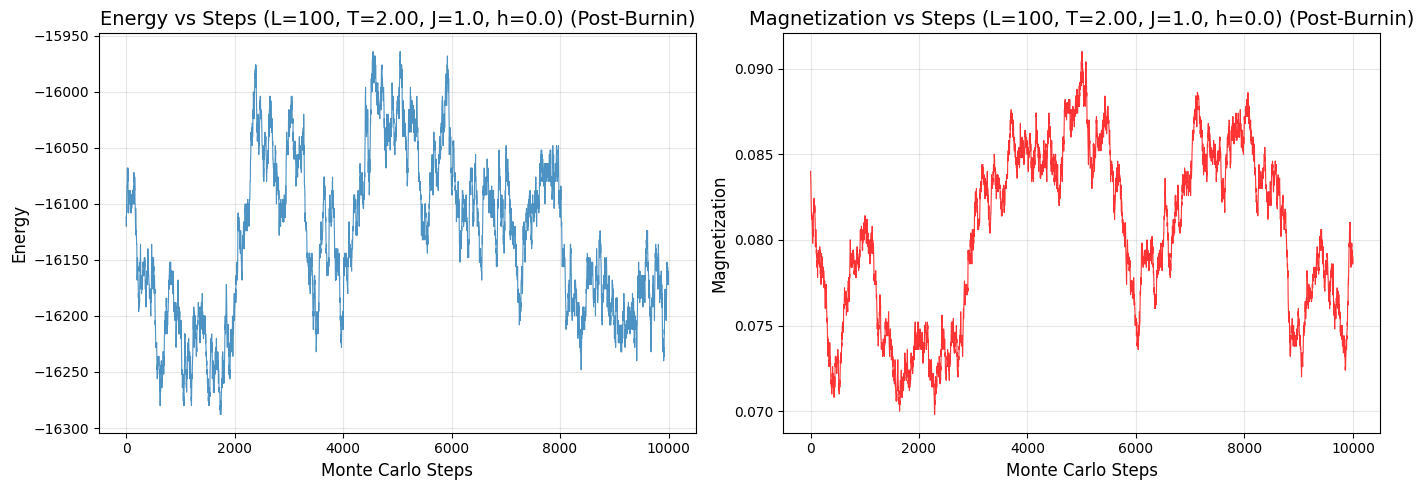

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.5000_config.png


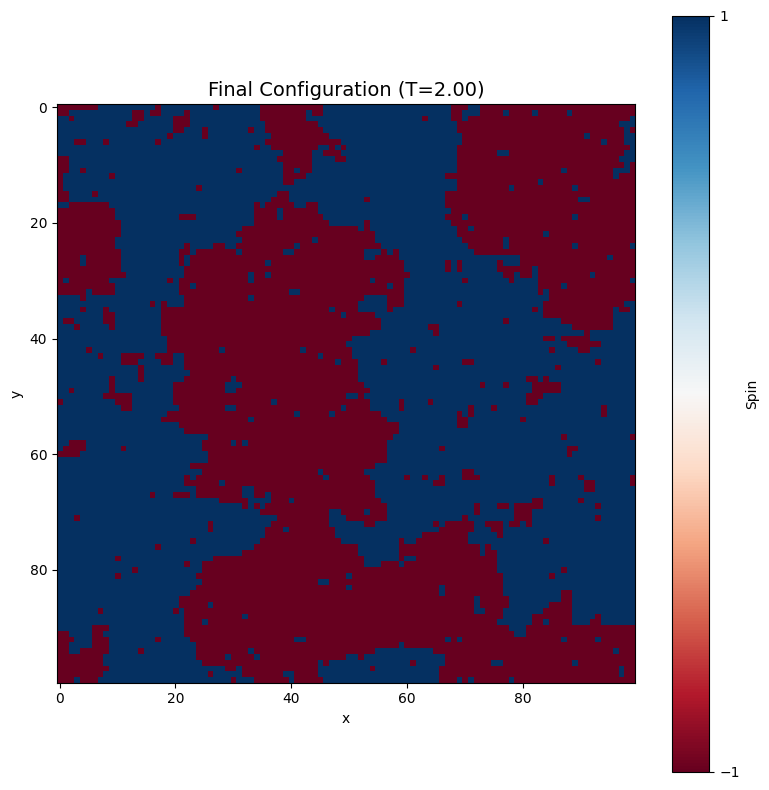

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.5.npz

[16/16] Simulating beta = 0.6000 (T = 1.6667)
Running simulation: L=100, T=1.667, J=1.0, h=0.0
Burn-in steps: 16666
Production steps: 100000, Recording every 10 steps
Phase 1: Burn-in... Complete (acceptance rate: 0.100)
Phase 2: Production run... Complete (acceptance rate: 0.075)

Equilibrium Statistics:
  <E> = -17472.4724 ± 150.3146
  <|M|> = 0.1038 ± 0.0084
  Plot saved: data/metropolis_temperature_scan/plots/beta_0.6000_timeseries.png


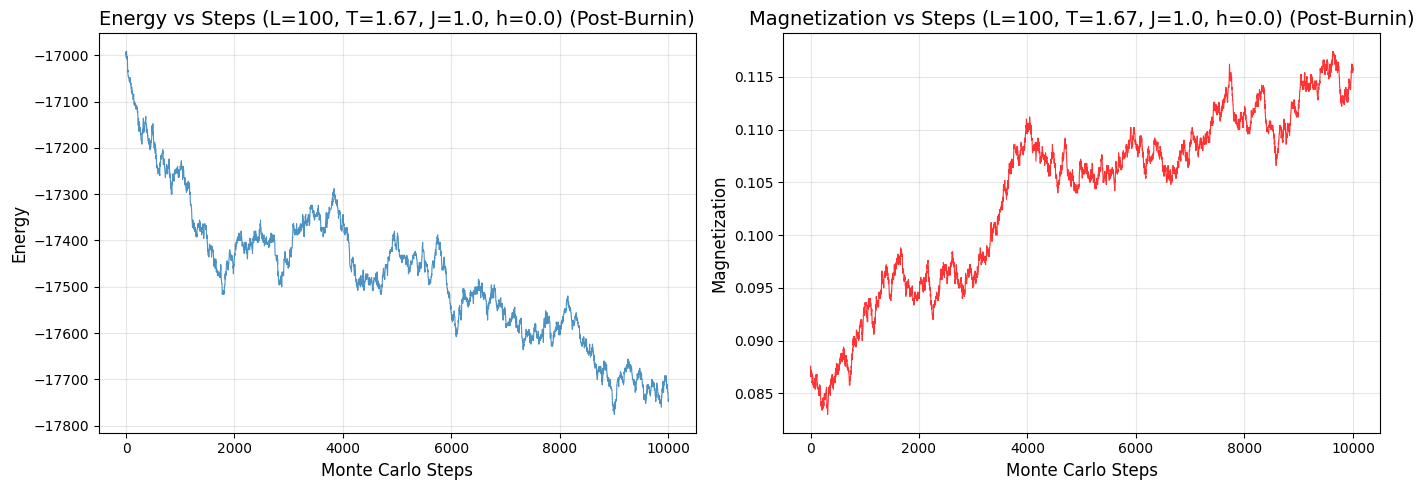

  Plot saved: data/metropolis_temperature_scan/plots/beta_0.6000_config.png


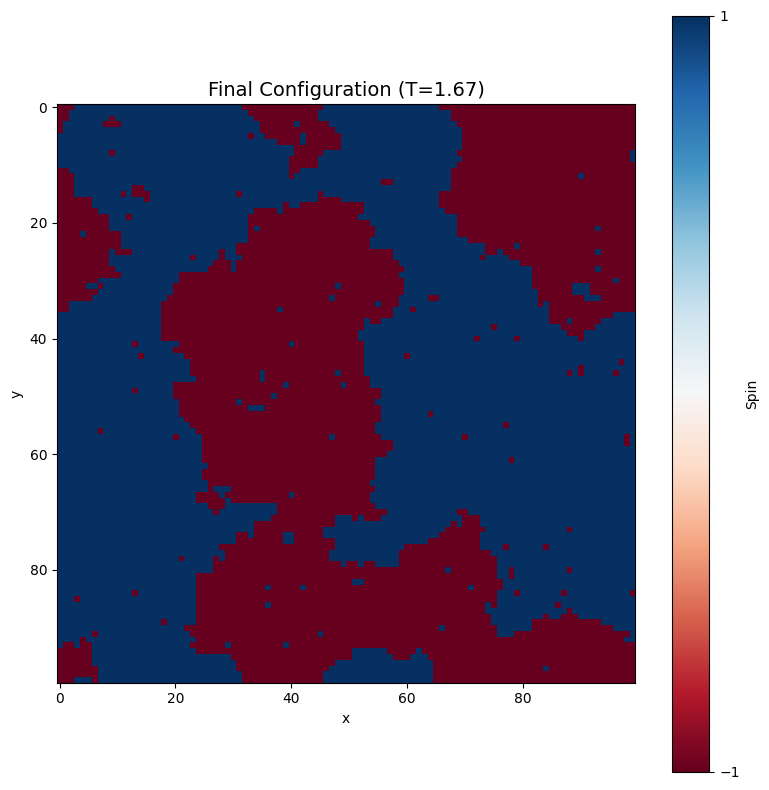

  Saved: data/metropolis_temperature_scan/mag_eng_beta_0.6.npz

Temperature scan completed!
Data saved in: data/metropolis_temperature_scan/
Plots saved in: data/metropolis_temperature_scan/plots/
All saved data is POST-BURNIN (equilibrated)


In [15]:
T_c = 2.269  # Critical temperature for 2D Ising model
beta_c = 1 / T_c  # = 0.4407

# Run definition
run = "metropolis_temperature_scan"

# Folder creation
if not os.path.exists(f'data/{run}'):
    os.makedirs(f'data/{run}')

# Create plots subdirectory
if not os.path.exists(f'data/{run}/plots'):
    os.makedirs(f'data/{run}/plots')

# Simulation parameters
J = 1.0          # Interaction strength
N = 100          # Lattice size
n_steps = 100_000  # Number of production steps

# Beta values to simulate
beta_ls = [
    0.1, 0.2, 0.3, 0.4, 0.41, 0.42, 0.43, 0.44, 0.4407, 
    0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.6
]

# Save run parameters
with open(f"data/{run}/_parameters.txt", "w") as f:
    f.write(f"Run: {run}\n")
    f.write(f"Algorithm: Metropolis with proper burn-in\n")
    f.write(f"Lattice size: {N}x{N}\n")
    f.write(f"Interaction strength J: {J}\n")
    f.write(f"Number of production steps: {n_steps}\n")
    f.write(f"Burn-in: Auto-calculated (5*N^2 base, 10x near T_c)\n")
    f.write(f"Critical temperature T_c: {T_c}\n")
    f.write(f"Critical beta beta_c: {beta_c:.4f}\n")
    f.write(f"Output files: data/{run}/mag_eng_beta_*.npz\n")
    f.write(f"Plots: data/{run}/plots/beta_*_[timeseries|config].png\n")
    f.write(f"Data: energies, magnetizations (post-burnin only)\n")

# Save beta list
with open(f"data/{run}/beta_list.txt", "w") as f:
    for beta in beta_ls:
        f.write(f"{beta}\n")

# Run simulations for all beta values
print("=" * 70)
print(f"Starting temperature scan: {len(beta_ls)} temperatures")
print(f"Lattice: {N}x{N}, Production steps: {n_steps}")
print("=" * 70)

results_dict = {}
previous_state = None

for idx, beta in enumerate(beta_ls, 1):
    T = 1.0 / beta
    print(f"\n[{idx}/{len(beta_ls)}] Simulating beta = {beta:.4f} "
          f"(T = {T:.4f})")
    
    # Use previous state for faster equilibration (only for similar temps)
    if previous_state is not None and idx > 1:
        # Shorter burn-in when continuing from nearby temperature
        burnin = determine_burnin_steps(N, beta) // 3
        initial = previous_state
    else:
        # Full burn-in for first simulation
        burnin = None
        initial = None
    
    # Prepare plot save prefix
    plot_prefix = f"data/{run}/plots/beta_{beta:.4f}"
    
    # Run simulation
    result = simulate_ising_model(
        L=N,
        T=T,
        J=J,
        h=0.0,
        n_steps=n_steps,
        burnin_steps=burnin,
        record_interval=10,
        random_init=True,
        show_plots=True,  # Show plots during simulation
        initial_state=initial,
        save_plots_prefix=plot_prefix  # Save plots
    )
    
    # Store results
    results_dict[beta] = result
    previous_state = result['state']
    
    # Save equilibrated data only
    np.savez_compressed(
        f"data/{run}/mag_eng_beta_{beta}.npz", 
        energies=result['energies'], 
        magnetizations=result['magnetizations'],
        burnin_steps=result['parameters']['burnin_steps']
    )
    
    print(f"  Saved: data/{run}/mag_eng_beta_{beta}.npz")

print("\n" + "=" * 70)
print("Temperature scan completed!")
print(f"Data saved in: data/{run}/")
print(f"Plots saved in: data/{run}/plots/")
print("All saved data is POST-BURNIN (equilibrated)")
print("=" * 70)


Generating phase transition analysis...


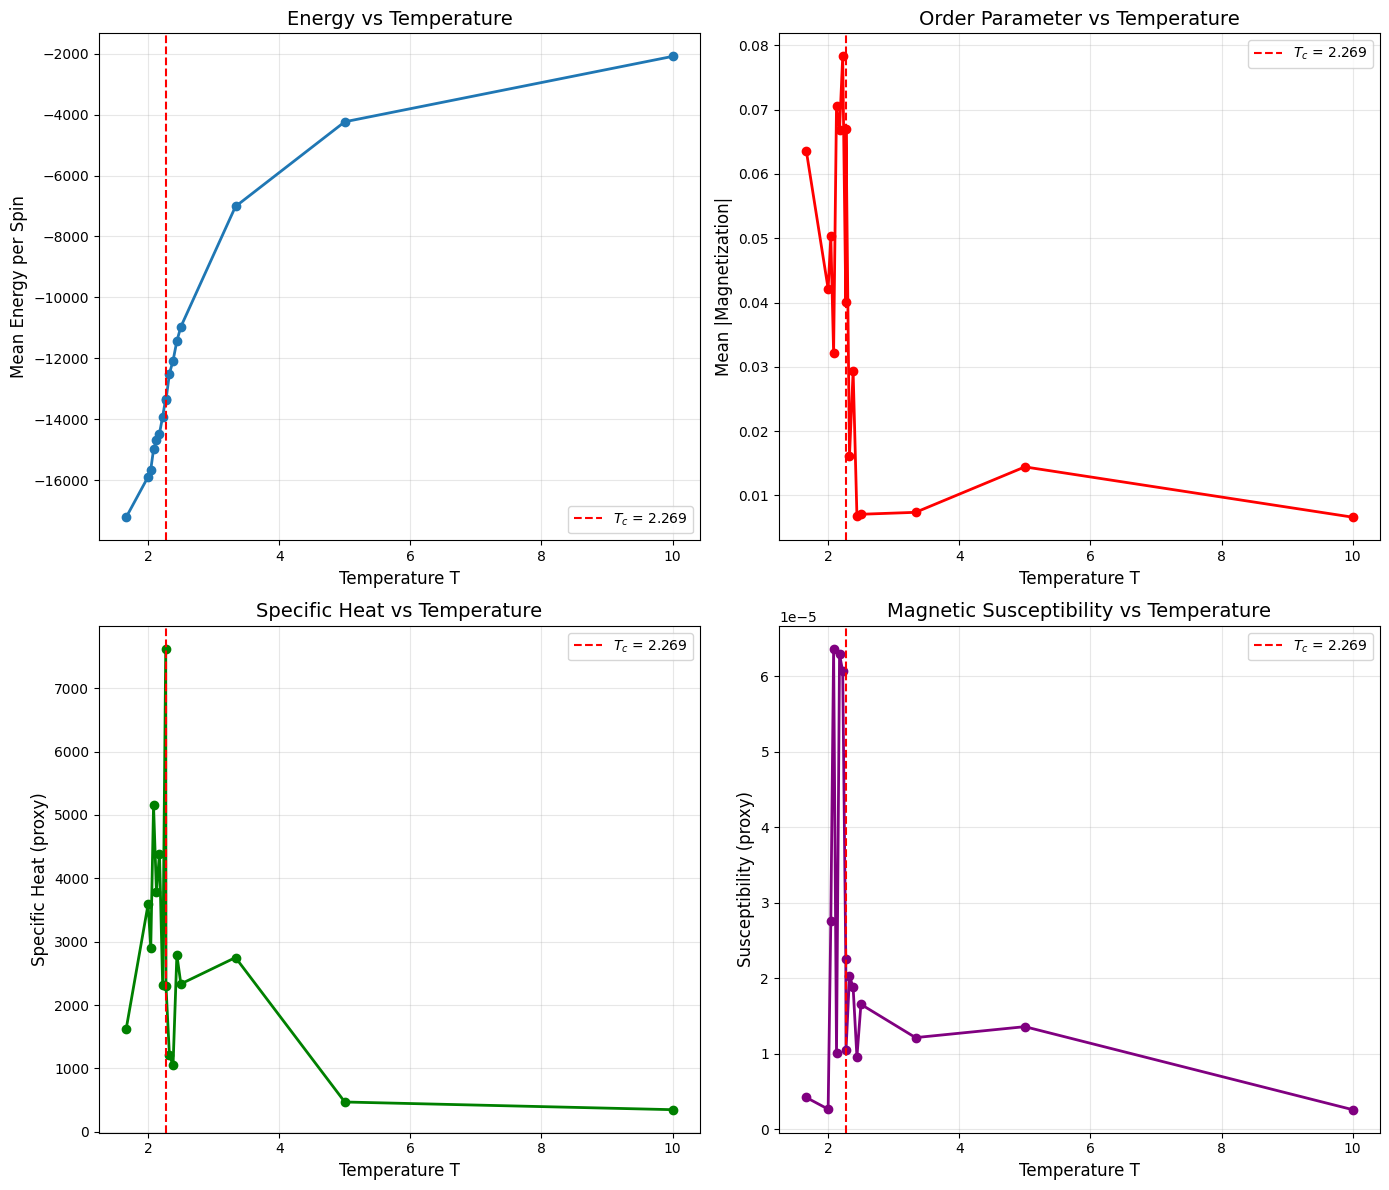

Phase transition plot saved: data/metropolis_temperature_scan/phase_transition_analysis.png


In [7]:
print("\nGenerating phase transition analysis...")

# Load all results
beta_values = []
mean_energies = []
mean_magnetizations = []
specific_heats = []
susceptibilities = []

for beta in beta_ls:
    data = np.load(f"data/{run}/mag_eng_beta_{beta}.npz")
    energies = data['energies']
    magnetizations = data['magnetizations']
    
    # Use second half for equilibrium averages
    burnin = len(energies) // 2
    E = energies[burnin:]
    M = np.abs(magnetizations[burnin:])
    
    beta_values.append(beta)
    mean_energies.append(np.mean(E))
    mean_magnetizations.append(np.mean(M))
    
    # Specific heat and susceptibility proxies
    specific_heats.append(beta**2 * np.var(E))
    susceptibilities.append(beta * np.var(M))

# Convert to arrays
beta_values = np.array(beta_values)
T_values = 1.0 / beta_values
mean_energies = np.array(mean_energies)
mean_magnetizations = np.array(mean_magnetizations)
specific_heats = np.array(specific_heats)
susceptibilities = np.array(susceptibilities)

# Create comprehensive phase transition plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Energy vs Temperature
axes[0, 0].plot(T_values, mean_energies, 'o-', linewidth=2, markersize=6)
axes[0, 0].axvline(T_c, color='red', linestyle='--', 
                   label=f'$T_c$ = {T_c:.3f}')
axes[0, 0].set_xlabel('Temperature T', fontsize=12)
axes[0, 0].set_ylabel('Mean Energy per Spin', fontsize=12)
axes[0, 0].set_title('Energy vs Temperature', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Magnetization vs Temperature
axes[0, 1].plot(T_values, mean_magnetizations, 'o-', 
                linewidth=2, markersize=6, color='red')
axes[0, 1].axvline(T_c, color='red', linestyle='--', 
                   label=f'$T_c$ = {T_c:.3f}')
axes[0, 1].set_xlabel('Temperature T', fontsize=12)
axes[0, 1].set_ylabel('Mean |Magnetization|', fontsize=12)
axes[0, 1].set_title('Order Parameter vs Temperature', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Specific Heat vs Temperature
axes[1, 0].plot(T_values, specific_heats, 'o-', 
                linewidth=2, markersize=6, color='green')
axes[1, 0].axvline(T_c, color='red', linestyle='--', 
                   label=f'$T_c$ = {T_c:.3f}')
axes[1, 0].set_xlabel('Temperature T', fontsize=12)
axes[1, 0].set_ylabel('Specific Heat (proxy)', fontsize=12)
axes[1, 0].set_title('Specific Heat vs Temperature', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Susceptibility vs Temperature
axes[1, 1].plot(T_values, susceptibilities, 'o-', 
                linewidth=2, markersize=6, color='purple')
axes[1, 1].axvline(T_c, color='red', linestyle='--', 
                   label=f'$T_c$ = {T_c:.3f}')
axes[1, 1].set_xlabel('Temperature T', fontsize=12)
axes[1, 1].set_ylabel('Susceptibility (proxy)', fontsize=12)
axes[1, 1].set_title('Magnetic Susceptibility vs Temperature', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'data/{run}/phase_transition_analysis.png', dpi=150)
plt.show()

print(f"Phase transition plot saved: data/{run}/phase_transition_analysis.png")


In [8]:
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"{'Beta':>8} {'T':>8} {'<E>':>12} {'<|M|>':>12} {'C_v':>12} {'χ':>12}")
print("-" * 70)

for i, beta in enumerate(beta_ls):
    T = T_values[i]
    print(f"{beta:8.4f} {T:8.4f} {mean_energies[i]:12.6f} "
          f"{mean_magnetizations[i]:12.6f} {specific_heats[i]:12.6f} "
          f"{susceptibilities[i]:12.6f}")

print("=" * 70)


SUMMARY STATISTICS
    Beta        T          <E>        <|M|>          C_v            χ
----------------------------------------------------------------------
  0.1000  10.0000 -2085.153369     0.006621   350.191472     0.000003
  0.2000   5.0000 -4233.109378     0.014444   471.472595     0.000014
  0.3000   3.3333 -7014.762647     0.007377  2750.507245     0.000012
  0.4000   2.5000 -10964.358328     0.007075  2334.352390     0.000017
  0.4100   2.4390 -11434.370726     0.006840  2792.612214     0.000010
  0.4200   2.3810 -12076.191162     0.029345  1052.716021     0.000019
  0.4300   2.3256 -12504.036793     0.016130  1210.046281     0.000020
  0.4400   2.2727 -13380.172765     0.066920  2308.301461     0.000010
  0.4407   2.2691 -13327.428914     0.040130  7620.107829     0.000023
  0.4500   2.2222 -13915.488902     0.078290  2322.355909     0.000061
  0.4600   2.1739 -14470.566687     0.066908  4389.672338     0.000063
  0.4700   2.1277 -14698.591482     0.070646  3783.523184    